Notebook to determine copy correction procedure from toy example. 

1. Start with toy example of fully synchronized reads. Show that we can transform from the equal total read count matrix to the copy number matrix.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Copy number matrix, each row is an origin
# each column is a timepoint
V = np.array([[2, 2, 2],
              [1, 2, 2],
              [1, 1, 2]])
n = V.shape[0]

# total copy number counts for each timepoint
counts = V.sum(axis=0)
counts_reshape = counts.reshape((1, -1))

# Transform to equal sum counts
V_prime = (V * n / counts_reshape)

# Reconstruct V to show the reverse transformation is possible
recontructed_V = V_prime * counts_reshape / n


Text(0.5, 1.0, 'Copy number counts\nreconstructed')

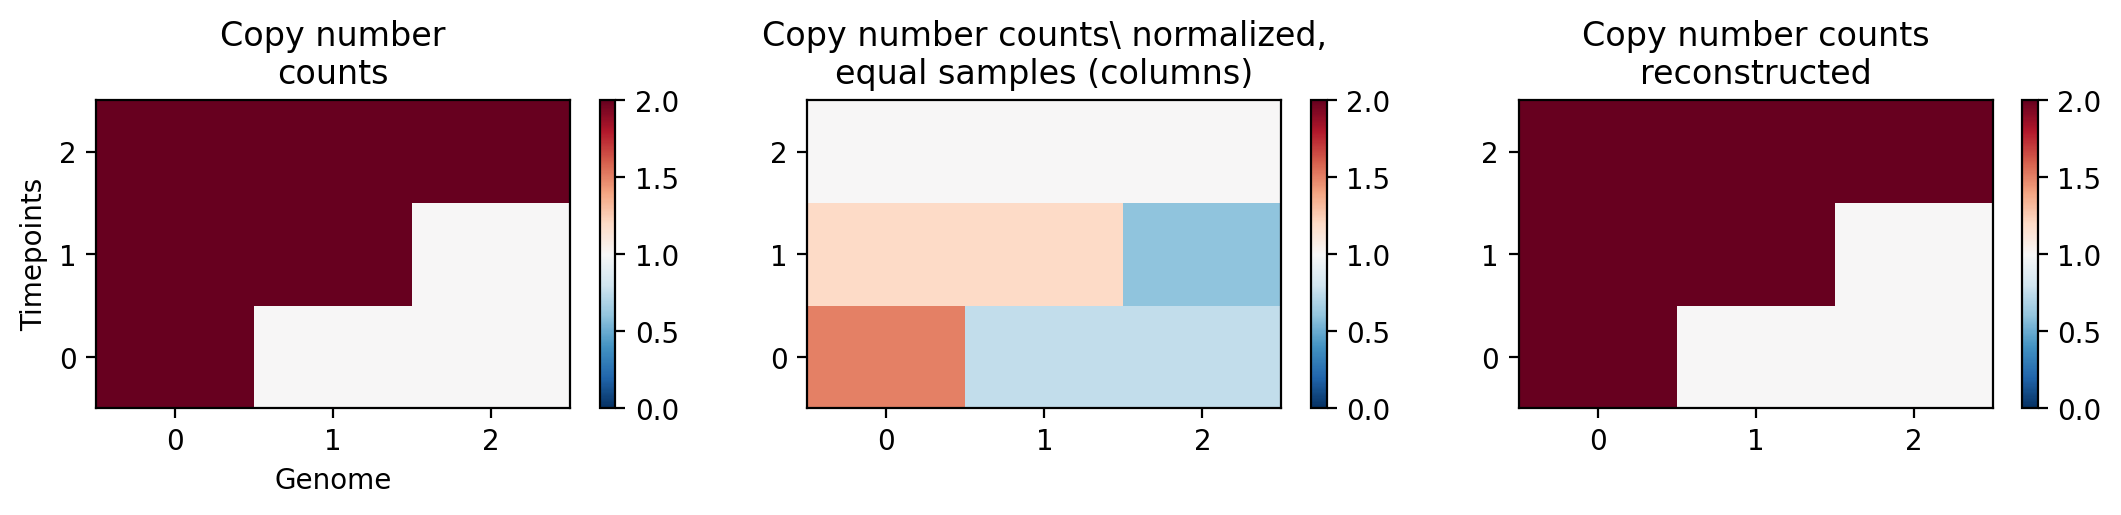

In [3]:
plt.figure(figsize=(13, 2))
plt.subplot(1, 3, 1)
plt.imshow(V.T, aspect='auto', cmap='RdBu_r', vmin=0, vmax=2, origin='lower')
plt.colorbar()
plt.title("Copy number\ncounts")
plt.ylabel("Timepoints")
plt.xlabel("Genome")

plt.subplot(1, 3, 2)
plt.imshow(V_prime.T, aspect='auto', cmap='RdBu_r', vmin=0, vmax=2, origin='lower')
plt.colorbar()
plt.title("Copy number counts\ normalized,\nequal samples (columns)")

plt.subplot(1, 3, 3)
plt.imshow(recontructed_V.T, aspect='auto', cmap='RdBu_r', vmin=0, vmax=2, origin='lower')
plt.colorbar()
plt.title("Copy number counts\nreconstructed")

In [4]:
# Let's take a replication profile and convert it into the equal sample example...
path = 'data/replication_timing/yl_2019/chrom_replication_timing_shared.csv'
chrom_repl_profile = pd.read_csv(path).set_index(['chr', 'start'])
chrom10_replication_profile = chrom_repl_profile.loc[10]

num_indices = 30
n = chrom10_replication_profile.shape[0]

copy_number_matrix = np.ones((n, num_indices))
    
for i in range(chrom10_replication_profile.shape[0]):
    replication_index = chrom10_replication_profile.iloc[i].replication_index-100
    copy_number_matrix[i, replication_index:] = 2


Text(0, 0.5, 'Timepoints')

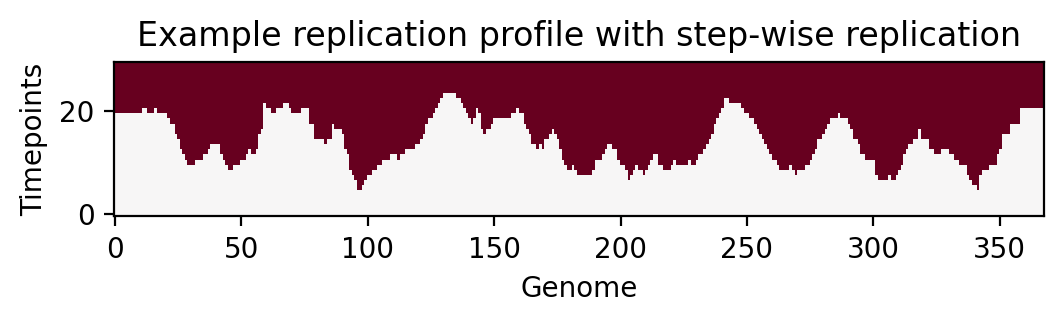

In [5]:
plt.figure(figsize=(6, 1))
plt.imshow(copy_number_matrix.T, origin='lower', aspect='auto', vmin=0, vmax=2, 
          cmap='RdBu_r', interpolation='none')
plt.title("Example replication profile with step-wise replication")
plt.xlabel("Genome")
plt.ylabel("Timepoints")

In [6]:
# Number of origins that have replicated per timepoint
k = (copy_number_matrix > 1).sum(axis=0)
total_copy_number = k*2 + (n-k)
total_copy_number_reshaped = total_copy_number.reshape((1, -1))

normalized_copy_numbers = copy_number_matrix * n / total_copy_number_reshaped

In [7]:
chrom10_replication_profile['genomic_index'] = np.arange(len(chrom10_replication_profile))
replication_sorted_arr_index = chrom10_replication_profile.sort_values('replication_index')['genomic_index']

Text(0.5, 1.0, 'Copy number reconstructed')

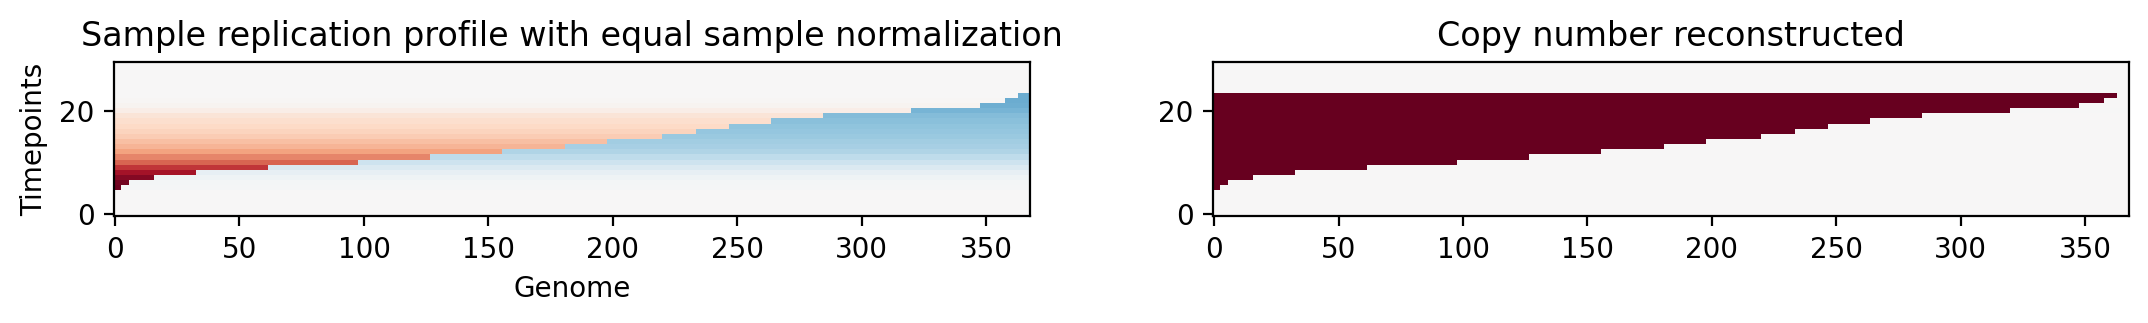

In [8]:
plt.figure(figsize=(13, 1))

sorted_normalized_dat = normalized_copy_numbers.T[:, replication_sorted_arr_index]

plt.subplot(1, 2, 1)
plt.imshow(sorted_normalized_dat, origin='lower', aspect='auto', vmin=0, vmax=2, 
          cmap='RdBu_r', interpolation='none')
plt.title("Sample replication profile with equal sample normalization")
plt.xlabel("Genome")
plt.ylabel("Timepoints")

# Estimate the total copy number from the normalized data by 
# counting up regions greater than 1...
total_copy_number_estimation = ((normalized_copy_numbers > 1)+1).sum(axis=0)
copy_number_reconstructed = normalized_copy_numbers * \
    total_copy_number_estimation.reshape((1, -1)) / n

plt.subplot(1, 2, 2)
plt.imshow(copy_number_reconstructed.T[:, replication_sorted_arr_index], 
           origin='lower', aspect='auto', vmin=0, vmax=2, 
          cmap='RdBu_r', interpolation='none')
plt.title("Copy number reconstructed")

# Reconstsru

Text(0.5, 1.0, 'Total copy curve, C')

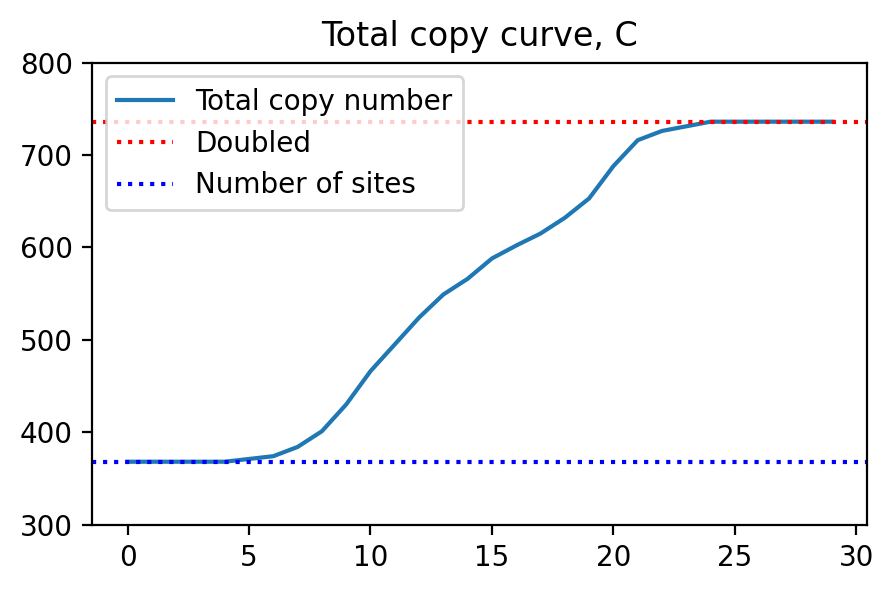

In [9]:
plt.figure(figsize=(5, 3))

total_copies_per_time = copy_number_matrix.sum(axis=0)
plt.plot(total_copies_per_time, label="Total copy number")
plt.axhline(368*2, c='red', label="Doubled", ls='dotted')
plt.axhline(368, c='blue', label="Number of sites", ls='dotted')
plt.legend()
plt.ylim(300, 800)
plt.title("Total copy curve, C")

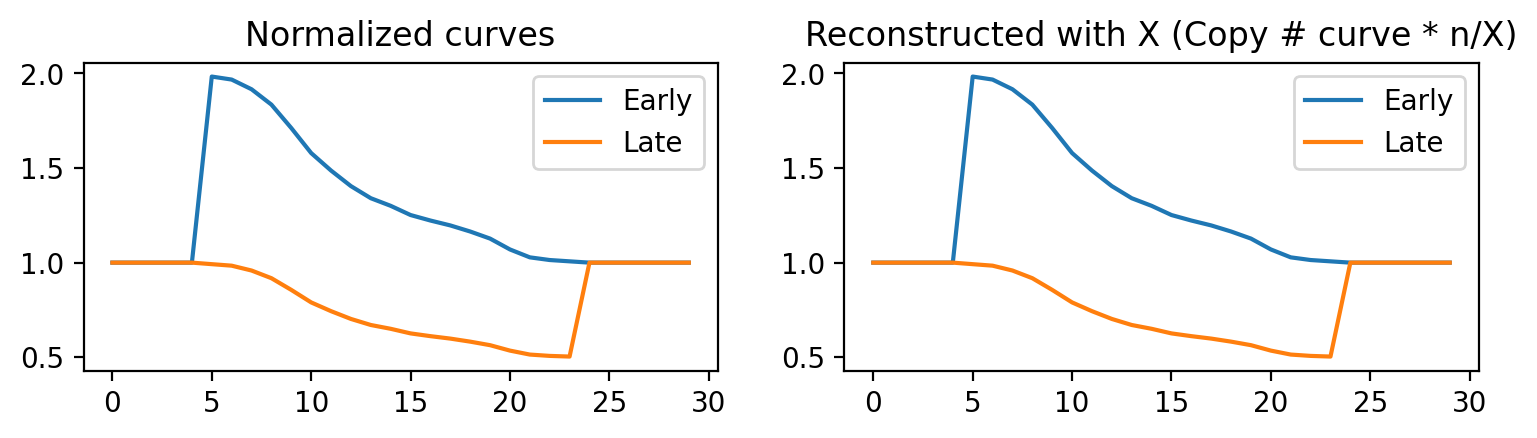

In [10]:
plt.figure(figsize=(9, 2))
plt.subplot(1, 2, 1)
plt.plot(sorted_normalized_dat[:, 0], label='Early')
plt.plot(sorted_normalized_dat[:, -1], label='Late')
plt.legend()
plt.title("Normalized curves")

plt.subplot(1, 2, 2)
true_early_copy_curve = copy_number_matrix[replication_sorted_arr_index][0]
true_late_copy_curve = copy_number_matrix[replication_sorted_arr_index][-1]
plt.plot(true_early_copy_curve * n/total_copies_per_time,
        label="Early")
plt.plot(true_late_copy_curve * n/total_copies_per_time,
       label="Late")
plt.title("Reconstructed with X (Copy # curve * n/X)")
plt.legend()
# Not quite right, there is something going on with the divisor in 
# the subtrahend (subtracting term)


Text(0.5, 1.0, 'Derivation of copy curve, X')

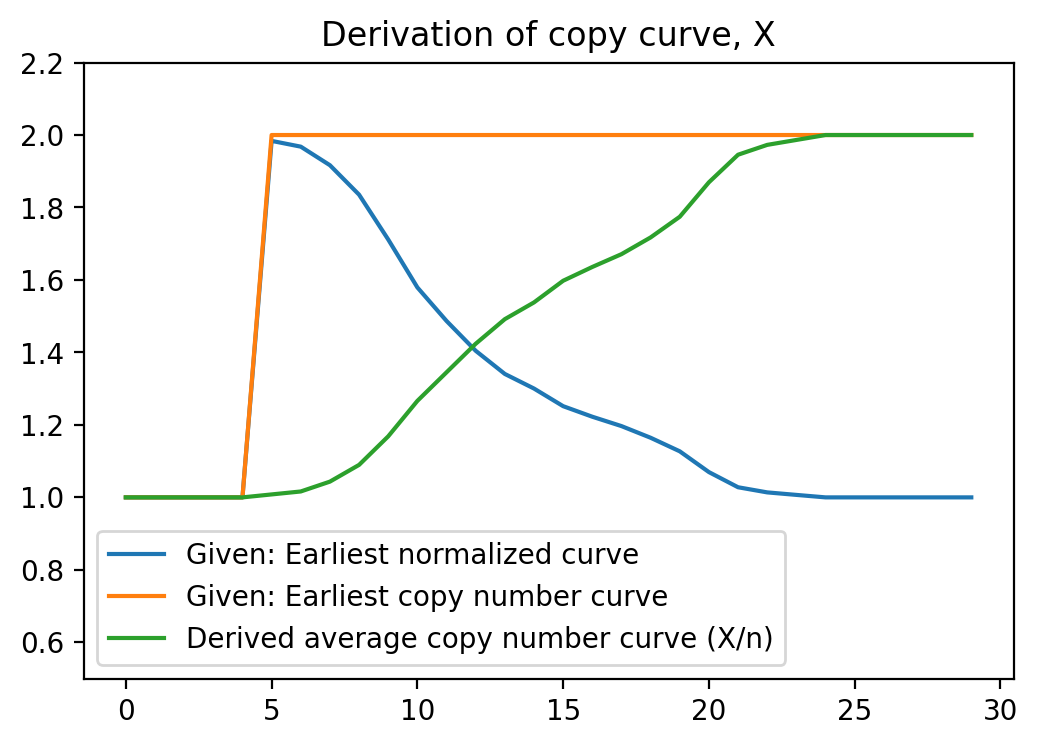

In [203]:
# From the earliest timepoint, can we reconstruct X?

earliest_normalized_curve = sorted_normalized_dat[:, 0]
latest_normalized_curve = sorted_normalized_dat[:, -1]

# We know what the true copy curve looks like for this replicaiton time, so compute
derived_total_copy_curve = 1/(earliest_normalized_curve/true_early_copy_curve/n)

plt.figure(figsize=(6, 4))
plt.plot(earliest_normalized_curve, label="Given: Earliest normalized curve")
plt.plot(true_early_copy_curve, label="Given: Earliest copy number curve")
plt.plot(derived_total_copy_curve/n, label="Derived average copy number curve (X/n)")
plt.legend()
plt.ylim(0.5, 2.2)
plt.title("Derivation of copy curve, X")

Text(0.5, 1.0, 'Copy number reconstructed')

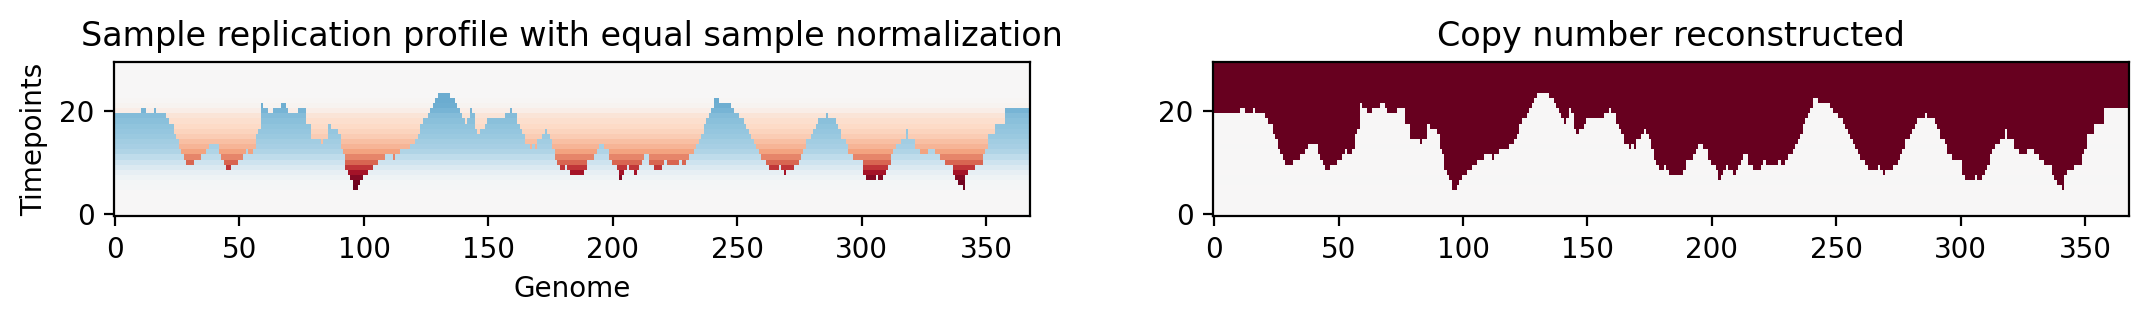

In [12]:
plt.figure(figsize=(13, 1))

plt.subplot(1, 2, 1)
plt.imshow(normalized_copy_numbers.T, origin='lower', aspect='auto', vmin=0, vmax=2, 
          cmap='RdBu_r', interpolation='none')
plt.title("Sample replication profile with equal sample normalization")
plt.xlabel("Genome")
plt.ylabel("Timepoints")

# Estimate the total copy number from the normalized data by 
# counting up regions greater than 1...
copy_number_reconstructed = normalized_copy_numbers * \
    derived_total_copy_curve.reshape((1, -1)) / n

plt.subplot(1, 2, 2)
plt.imshow(copy_number_reconstructed.T, origin='lower', aspect='auto', vmin=0, vmax=2, 
          cmap='RdBu_r', interpolation='none')
plt.title("Copy number reconstructed")

# Reconstsru

In [13]:
# Aside analysis to see what the raw data looks like when sorted by replication timing
# and an ad-hoc measure of replication timing using rank ordering....

In [14]:
normalized_copy_numbers.shape

(368, 30)

Text(0.5, 1.0, 'Simple synchronized H matrix')

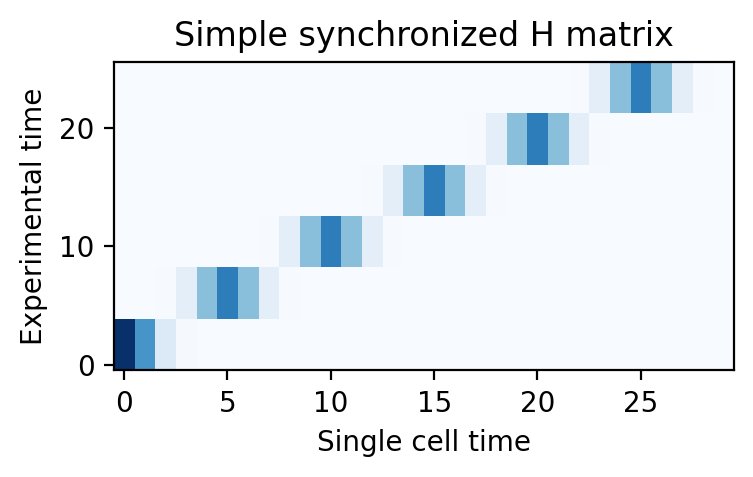

In [15]:
# Create an H with 5 timepoints that converts the above "true" replication timing
# into an "experimental" timecourse.

from scipy.stats.distributions import norm

single_cell_timepoints = np.arange(0, 30, 1)
experimental_timepoints = np.arange(0, 30, 5)

simple_H = np.zeros((len(experimental_timepoints), len(single_cell_timepoints)))

for i, x in enumerate(experimental_timepoints):
    ys = norm.pdf(single_cell_timepoints, x, 1)
    ys = ys/ys.sum()
    simple_H[i, :] = ys

plt.figure(figsize=(4, 2))
plt.imshow(simple_H,
          extent=[single_cell_timepoints[0]-.5, single_cell_timepoints[-1]+.5,
                  experimental_timepoints[0]-.5, experimental_timepoints[-1]+.5],
          aspect='auto', origin='lower', cmap='Blues')
plt.xlabel("Single cell time")
plt.ylabel("Experimental time")
plt.title("Simple synchronized H matrix")


In [16]:
normalized_copy_numbers.T.shape, simple_H.shape

((30, 368), (6, 30))

Text(0.5, 0.98, 'High resolution replication profile to experimental read counts')

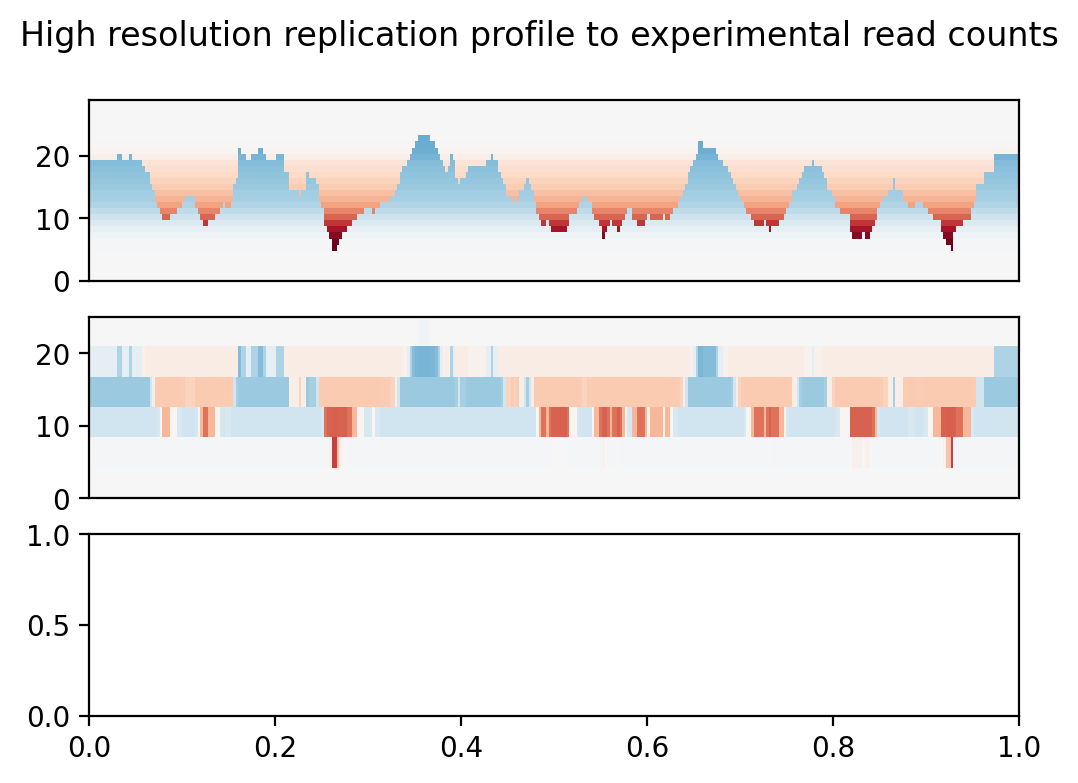

In [19]:
experimental_data_G = simple_H @ normalized_copy_numbers.T

plt.figure(figsize=(6, 4))
plt.subplot(3, 1, 1)
plt.imshow(normalized_copy_numbers.T, vmin=0, vmax=2, cmap='RdBu_r', origin='lower', 
    aspect='auto', interpolation='none', extent=[experimental_data_G.shape[0], experimental_data_G.shape[1],
                                                0, single_cell_timepoints[-1]])
plt.xticks([])

plt.subplot(3, 1, 2)
plt.imshow(experimental_data_G, vmin=0, vmax=2, cmap='RdBu_r', origin='lower', aspect='auto', 
          interpolation='none', extent=[experimental_data_G.shape[0],
                                        experimental_data_G.shape[1],
                                                0, experimental_timepoints[-1]])
plt.xticks([])

# plt.subplot(3, 1, 3)
#reconstructed_F = np.linalg.pinv(simple_H) @ G
#plt.imshow(reconstructed_F, vmin=0, vmax=2, cmap='RdBu_r', origin='lower', 
#    aspect='auto', interpolation='none', extent=[G.shape[0], G.shape[1],
#                                                0, single_cell_timepoints[-1]])

plt.suptitle("High resolution replication profile to experimental read counts")

In [20]:
# Sort by the max to get an approximation of the early to late replication timing
sorted_indices = np.argsort(normalized_copy_numbers.max(axis=1))[::-1]
sorted_indices_G = np.argsort(experimental_data_G.max(axis=0))[::-1]

Text(0.5, 1.0, 'Normalized, G copy numbers')

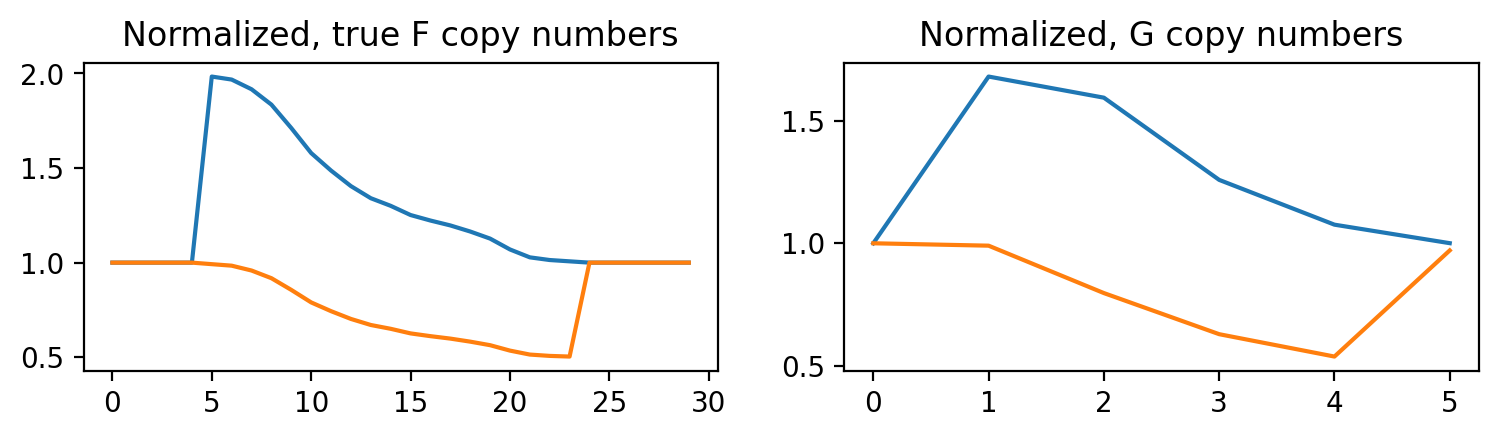

In [21]:
plt.figure(figsize=(9, 2))
plt.subplot(1, 2, 1)

# Here are the earliest and latest timepoints...
plt.plot(normalized_copy_numbers[sorted_indices][0])
plt.plot(normalized_copy_numbers[sorted_indices][-1])
plt.title("Normalized, true F copy numbers")

plt.subplot(1, 2, 2)
# Here are the earliest and latest timepoints...
plt.plot(experimental_data_G[:, sorted_indices_G][:, 0])
plt.plot(experimental_data_G[:, sorted_indices_G][:, -1])
plt.title("Normalized, G copy numbers")


# Idea for deconvolution to find replication timing

Idea: Compute a consensus X curve from a set of early and late replicating regions (or the cleanest set of positions)

Use this fixed curve for the deconvolution of each of the individual sites independently...


Other idea is to use CLOCCS copy number curve as X-predefined....

In [76]:
# Take the early curve and X and attempt to reconstruct....
num_sites = len(normalized_copy_numbers)

indices = np.arange(0, experimental_data_G.shape[1])

# Here are the earliest and latest timepoints...
F = normalized_copy_numbers[indices]
G = experimental_data_G[:, :][:, indices]

H = simple_H

avg_copies_per_time = total_copies_per_time/num_sites

# True F
true_F = copy_number_matrix[sorted_indices][indices]

F.shape, G.shape, total_copies_per_time.shape

((368, 30), (6, 368), (30,))

In [80]:
from src.ToyReplication import ReplicationDeconvolution

replication_solver = ReplicationDeconvolution(true_F, H, G, avg_copies_per_time)

In [81]:
replication_solver.deconvolve()

0/368 - 00:00:00.000
50/368 - 00:00:02.308
100/368 - 00:00:04.647
150/368 - 00:00:07.006
200/368 - 00:00:09.256
250/368 - 00:00:11.654
300/368 - 00:00:14.188
350/368 - 00:00:16.561


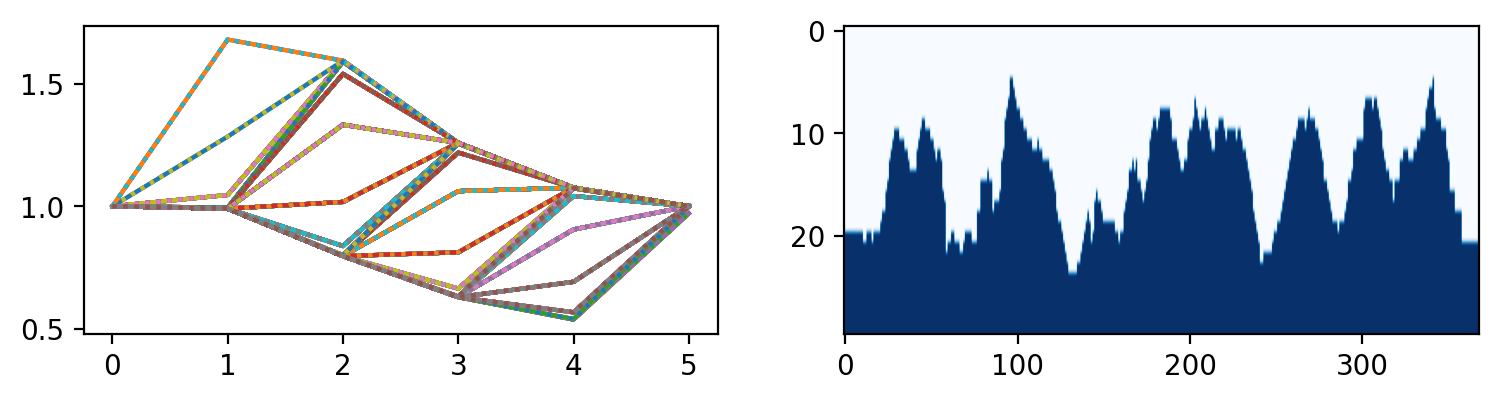

In [82]:
replication_solver.plot_result()

In [204]:
earliest_normalized_curve.reshape((-1, 1)).shape, H.shape
early_G = H @ earliest_normalized_curve
late_G = H @ latest_normalized_curve

In [235]:
from src.ToyReplication import AverageCopyNumberDeconvolution

avg_copy_solver = AverageCopyNumberDeconvolution(H)

In [272]:
avg_copy_solver.deconvolve(late_G)

00:00:00.957


In [320]:
# Iterate through all of the G indices and retrieve all of the estimated avg copy
# number curves, they won't agree, but hopefully the average across them will be close to the
# ground truth

from src.timer import Timer

timer = Timer()

n, m = H.shape
n, num_sites = experimental_data_G.shape

genomic_f_solutions = np.zeros((num_sites, m))
average_copy_curve_solutions = np.zeros((num_sites, m))
replication_indices = np.zeros(num_sites)

for genomic_index in range(num_sites):
    current_g = experimental_data_G[:, genomic_index]

    avg_copy_solver.deconvolve(current_g)
    genomic_f_solutions[genomic_index] = avg_copy_solver.f_solution
    average_copy_curve_solutions[genomic_index] = avg_copy_solver.avg_curve_solution
    replication_indices = avg_copy_solver.min_sol_idx
    
    if genomic_index % 20 == 0:
        timer.print_time(f"{genomic_index}/{num_sites}")


0/368 - 00:00:00.957
20/368 - 00:00:21.101
40/368 - 00:00:40.353
60/368 - 00:01:00.032
80/368 - 00:01:18.849
100/368 - 00:01:38.362
120/368 - 00:01:57.509
140/368 - 00:02:18.187
160/368 - 00:02:40.101
180/368 - 00:02:59.473
200/368 - 00:03:19.940
220/368 - 00:03:40.069
240/368 - 00:03:59.078
260/368 - 00:04:18.365
280/368 - 00:04:37.826
300/368 - 00:04:56.938
320/368 - 00:05:15.820
340/368 - 00:05:35.145
360/368 - 00:05:54.757


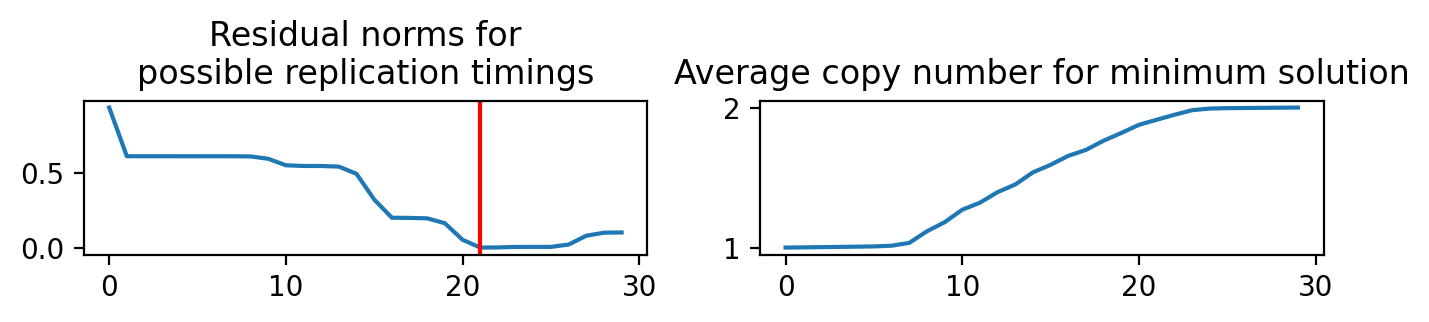

In [327]:
avg_copy_solver.plot_rn_curve()

Text(0.5, 1.0, 'All computed avg copy curves')

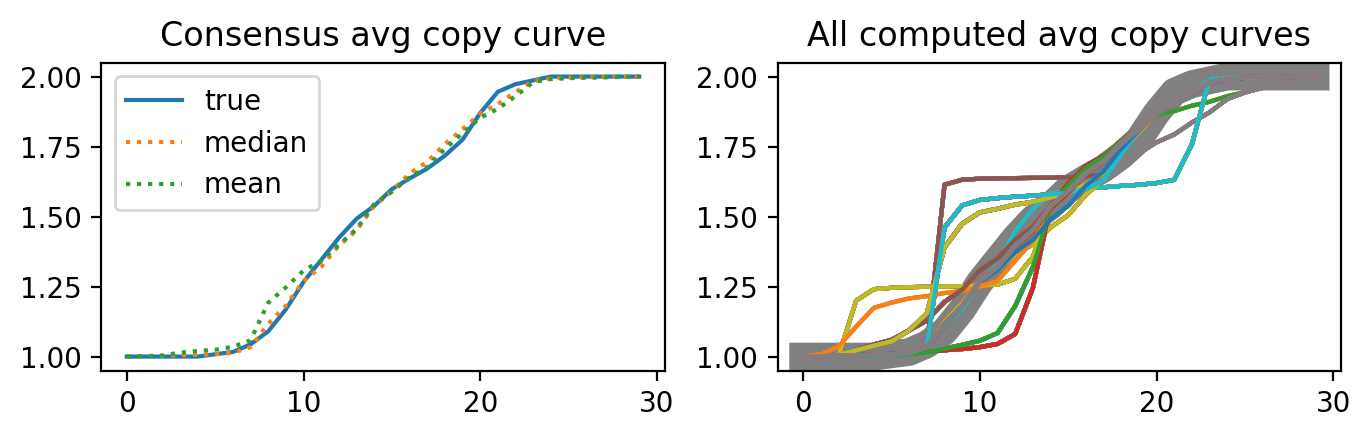

In [322]:
median_deconv_avg_copy_num = np.quantile(1/average_copy_curve_solutions.T, q=0.5, axis=1)
mean_deconv_avg_copy_num = np.mean(1/average_copy_curve_solutions.T, axis=1)

plt.figure(figsize=(8, 2))
plt.subplot(1, 2, 1)
plt.plot(avg_copies_per_time, label='true')
plt.plot(median_deconv_avg_copy_num, ls='dotted', label='median')
plt.plot(mean_deconv_avg_copy_num, ls='dotted', label='mean')
plt.legend()
plt.title("Consensus avg copy curve")

plt.subplot(1, 2, 2)
plt.plot(avg_copies_per_time, label='true', lw=10, c='gray', zorder=0)
plt.plot(1/average_copy_curve_solutions.T, zorder=1)
plt.title("All computed avg copy curves")


Text(0.5, 1.0, 'Predicted solution, individual average copy curves')

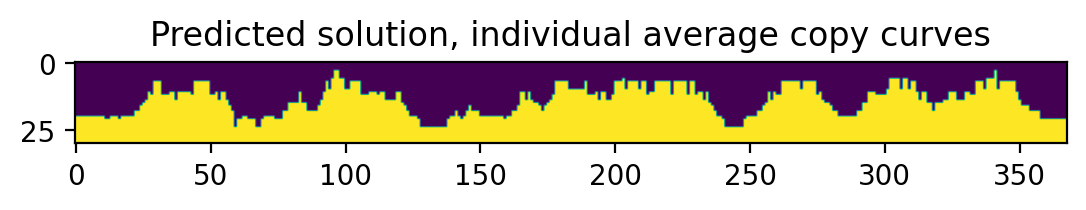

In [323]:
plt.imshow(genomic_f_solutions.T)
plt.title("Predicted solution, individual average copy curves")

In [324]:
from src.ToyReplication import ReplicationDeconvolution

est_copy_num_replication_solver = ReplicationDeconvolution(true_F, H, G, mean_deconv_avg_copy_num)
est_copy_num_replication_solver.deconvolve()

0/368 - 00:00:00.000
50/368 - 00:00:02.504
100/368 - 00:00:05.138
150/368 - 00:00:07.534
200/368 - 00:00:09.883
250/368 - 00:00:12.256
300/368 - 00:00:14.532
350/368 - 00:00:16.802


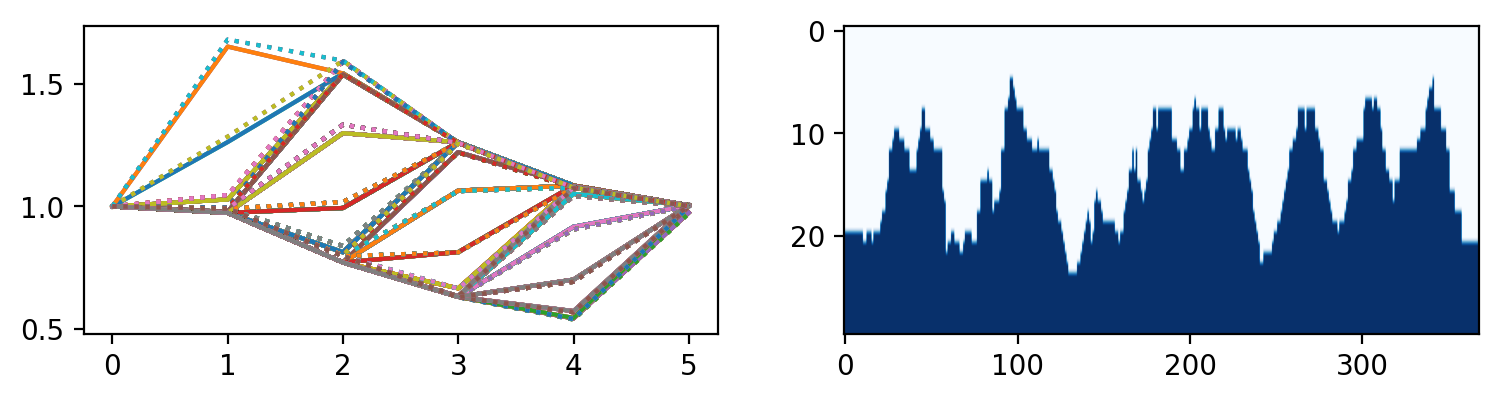

In [325]:
est_copy_num_replication_solver.plot_result()

([], [])

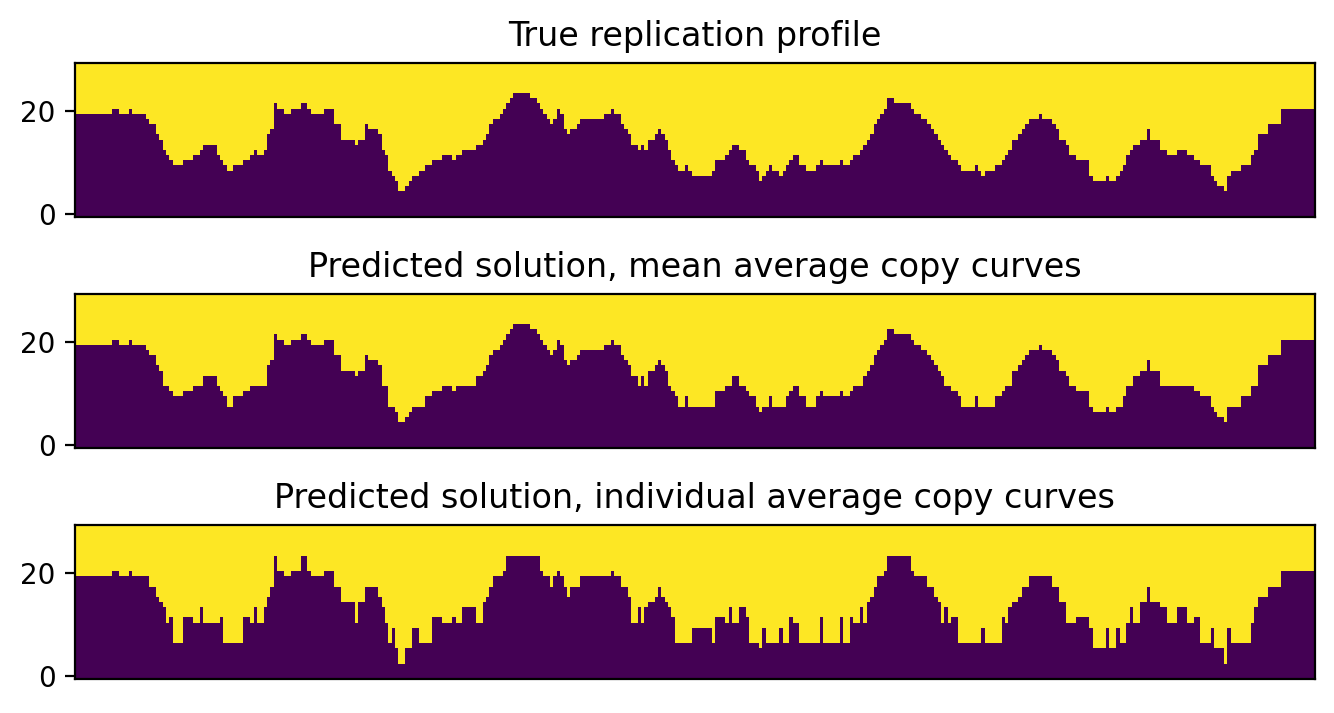

In [346]:
plt.figure(figsize=(8, 4))

plt.subplot(3, 1, 1)
plt.imshow(copy_number_reconstructed.T, origin='lower', aspect='auto', vmin=1, vmax=2,
          cmap='viridis', interpolation='none')
plt.title("True replication profile")
plt.xticks([])

plt.subplot(3, 1, 2)
plt.imshow(est_copy_num_replication_solver.F, origin='lower', aspect='auto', vmin=0, vmax=1,
          cmap='viridis', interpolation='none')
plt.title("Predicted solution, mean average copy curves")
plt.xticks([])

plt.subplot(3, 1, 3)
plt.imshow(genomic_f_solutions.T, origin='lower', aspect='auto', vmin=1, vmax=2,
          cmap='viridis', interpolation='none')
plt.title("Predicted solution, individual average copy curves")

plt.subplots_adjust(hspace=0.5)
plt.xticks([])

### Success in mixed simulated replication timing deconvolution.
Wednesday, December 4, 2024

1. Identified proper deconvolution of raw mixture data population:
   - Raw mixed data -> Estimated as H*F
   - Where F is the copy number, normalized by time (equal samples)
   - F is converted into unnormalized-raw copy number using X (the overall growth in copy number per time).
2. When X is known, the deconvolution is trivial and a proper replication curve is found.
3. When X is not known, it is estimated through individual genomic location estimations.
   - This estimation varies from location to location due to estimation errors.
   - Thus, in the toy example, we estimate X for all genomic locations. Then compute an average of these estimated X's.
4. Then, run the deconvolution to estimate F for all genomic locations to compute a replication timing.
   

## Real data example, Chromosome X, Replicate 1

Now, we will see if this workflow is resilient to the real data. Note that changes need to be made to the deconvolution process, as the indices in the deconvolution profile are different:
- We need to enforce continuity between RG1/CG1 and PostG1
- Replication timing can only exist in PostG1 (possibly only in S-phase).


In [349]:
from src.RealDataReplication import RealDataReplicationDeconvolution

real_deconv = RealDataReplicationDeconvolution()


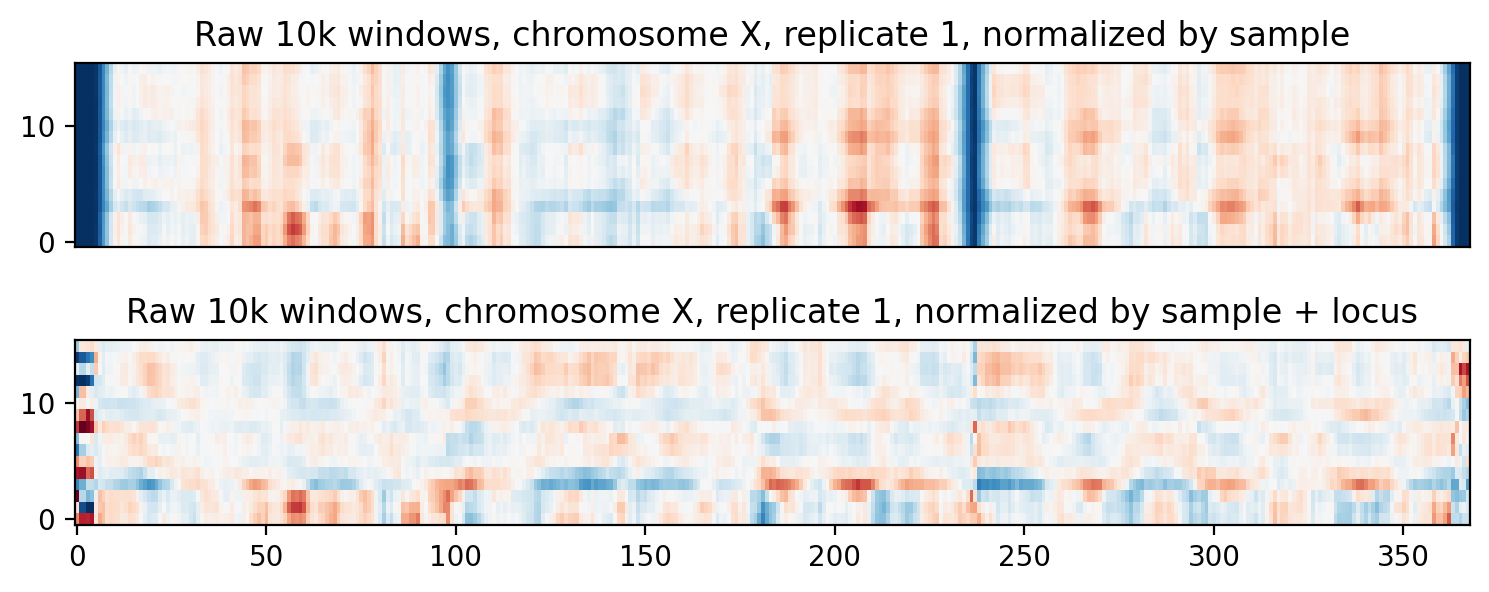

In [392]:
plt.figure(figsize=(9, 3))
plt.subplot(2, 1, 1)
plt.imshow(real_deconv.normalized_occupancy.T, origin='lower', aspect='auto', vmin=0, vmax=2,
          cmap='RdBu_r')
plt.xticks([])
plt.title("Raw 10k windows, chromosome X, replicate 1, normalized by sample")

plt.subplot(2, 1, 2)

normalized_by_columns = real_deconv.normalized_occupancy / real_deconv.normalized_occupancy.mean(axis=1).values.reshape((-1, 1))

plt.imshow(normalized_by_columns.T, origin='lower', aspect='auto', vmin=0.5, vmax=1.5,
          cmap='RdBu_r')
plt.title("Raw 10k windows, chromosome X, replicate 1, normalized by sample + locus")
plt.subplots_adjust(hspace=0.5)


Notable observation, the raw 10kb counts, when normalized by samples has places in the genome with many more reads than other locations.

If we are only concerned about copy number duplication, then perhaps it is reasonable to scale the genomic locii to the same general values... We are only concerned with count doubling at each location....

(16, 87)

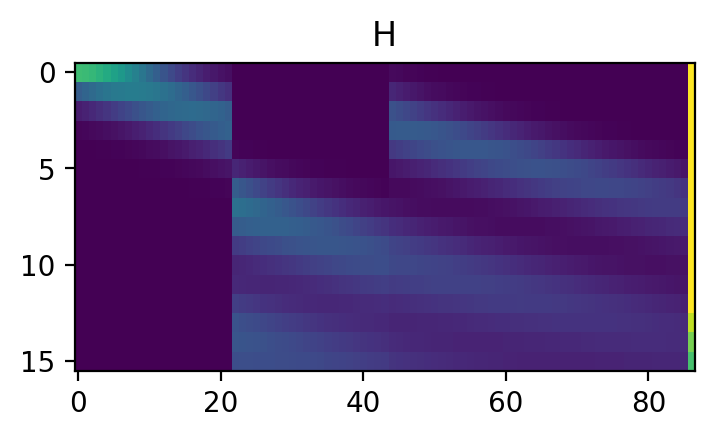

In [397]:
from src.config import load_configs_by_config_type

# Load the config for replicate 1
config, _ = load_configs_by_config_type('shared')
H, _ = config.calcH_function(config.intervals_wt1, config.WT1_TIMEPOINTS)
plt.figure(figsize=(4, 2))
plt.imshow(H, vmax=0.1, aspect='auto')
plt.title("H")
H.shape

Text(0.5, 1.0, 'Example curves\nnormalized by sample+column')

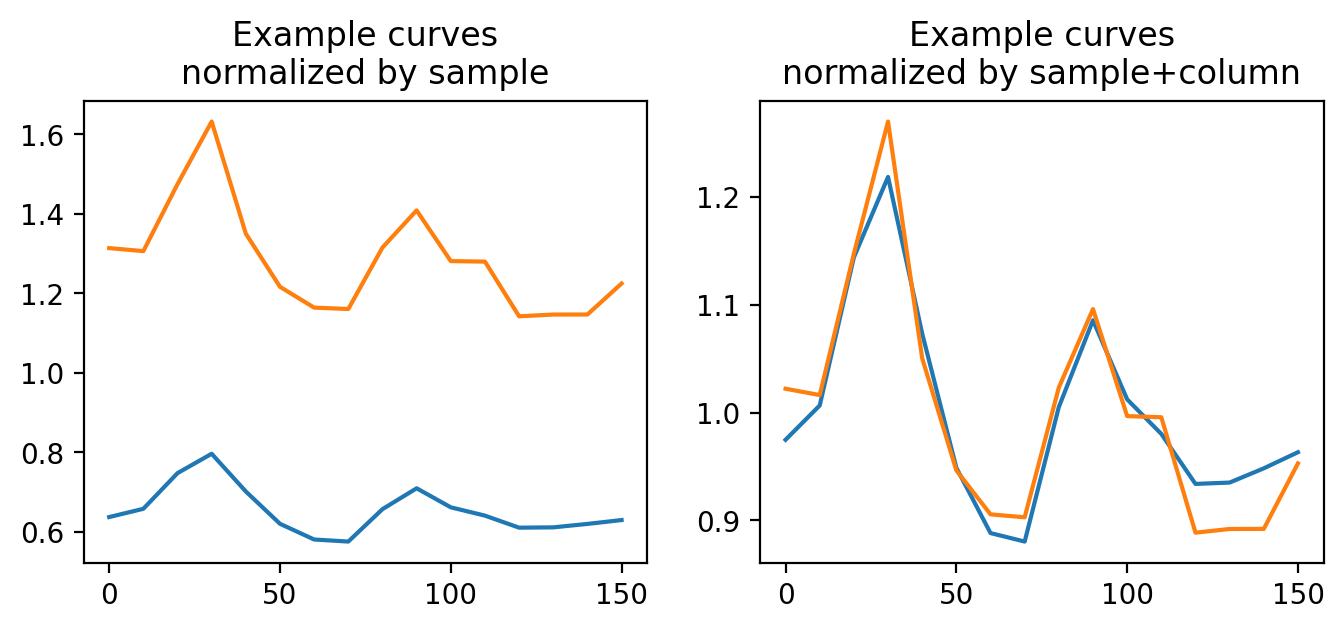

In [400]:
example_g_1 = real_deconv.normalized_occupancy.iloc[100]
example_g_2 = real_deconv.normalized_occupancy.iloc[-100]

normalized_example_g_1 = normalized_by_columns.iloc[100]
normalized_example_g_2 = normalized_by_columns.iloc[-100]

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.plot(example_g_1)
plt.plot(example_g_2)
plt.title("Example curves\nnormalized by sample")

plt.subplot(1, 2, 2)
plt.plot(normalized_example_g_1)
plt.plot(normalized_example_g_2)
plt.title("Example curves\nnormalized by sample+column")

In [441]:
CG1_indices = config.get_Hpositions_for_phase('CG1')
RG1_indices = config.get_Hpositions_for_phase('RG1')
postG1_indices = config.get_Hpositions_for_phase('postG1')

# CG1 and RG1 should be 1 throughout
# postG1 should be continuous and end with 0.5
from src.RealDataReplication import deconvolve_avg_copy_curve

n, m = H.shape

num_indices = len(postG1_indices)
rns = np.zeros(num_indices)
avg_curves = np.zeros((num_indices, m))
all_fs = np.zeros((num_indices, m))
all_predicted_gs = np.zeros((num_indices, n))

for i, replication_idx in enumerate(postG1_indices):
    rn, f, inv_learned_avg, predicted_g \
        = deconvolve_avg_copy_curve(normalized_example_g_1, config, H, replication_idx)
    rns[i] = rn
    all_fs[i] = f
    all_predicted_gs[i] = predicted_g
    avg_curves[i] = inv_learned_avg


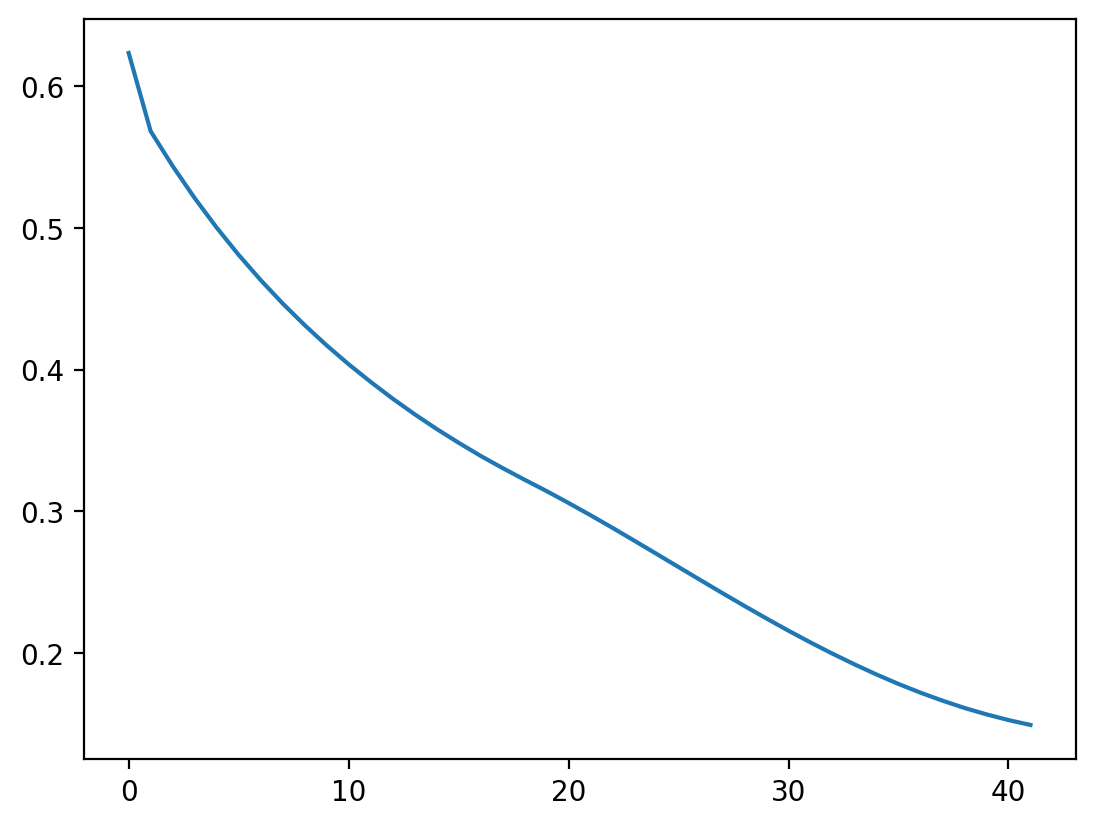

In [442]:
plt.plot(rns)

0

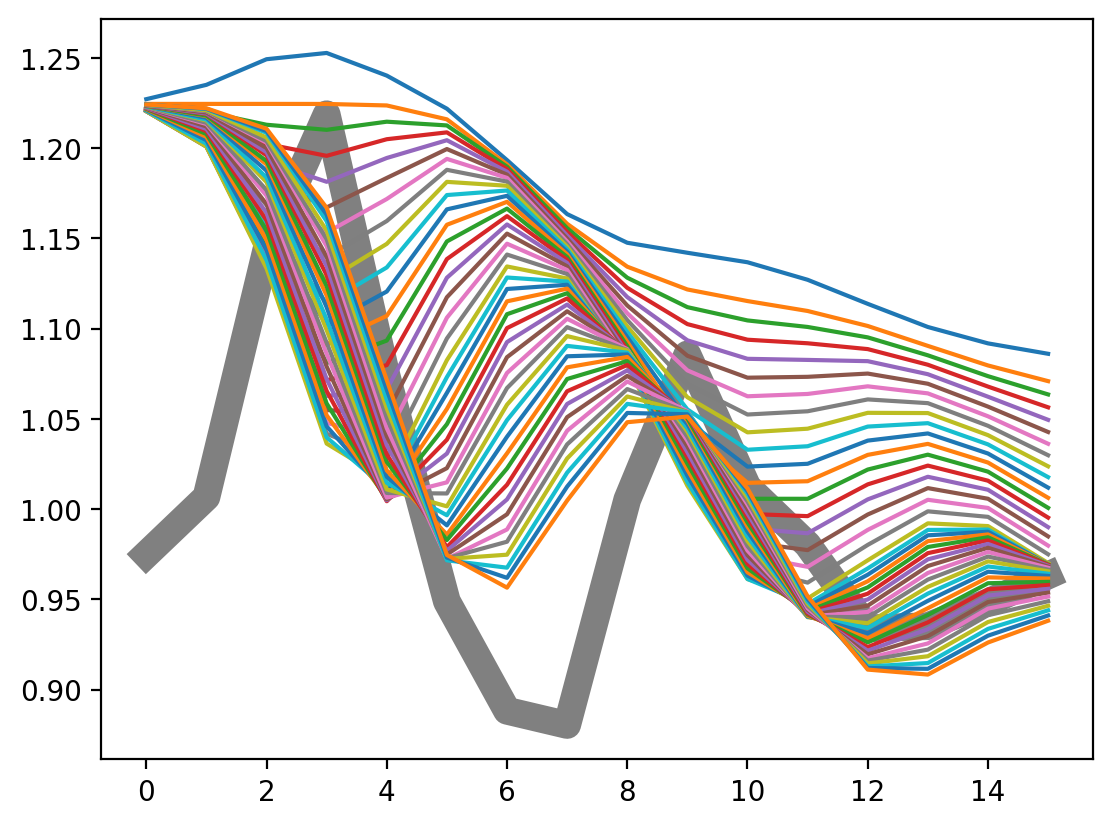

In [443]:
plt.plot(all_predicted_gs.T)
plt.plot(normalized_example_g_1.values, c='gray', lw=10, zorder=0)
0

0

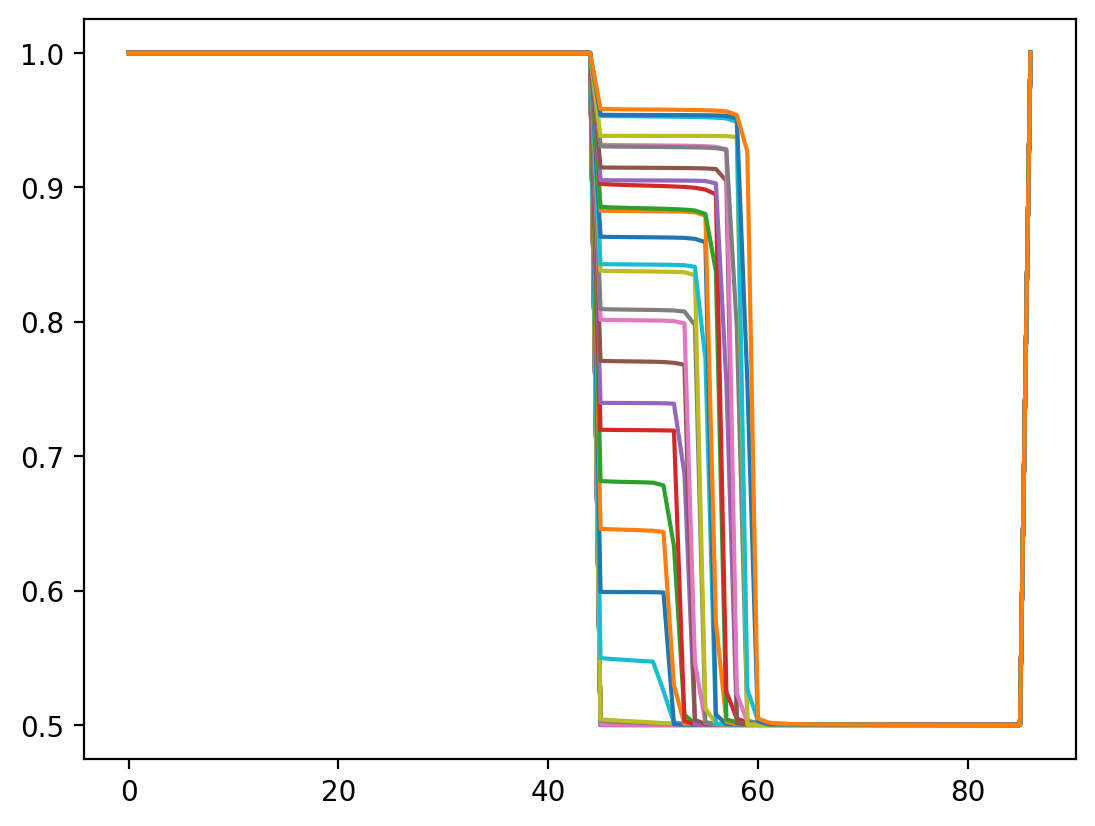

In [444]:
plt.plot(avg_curves.T)
0

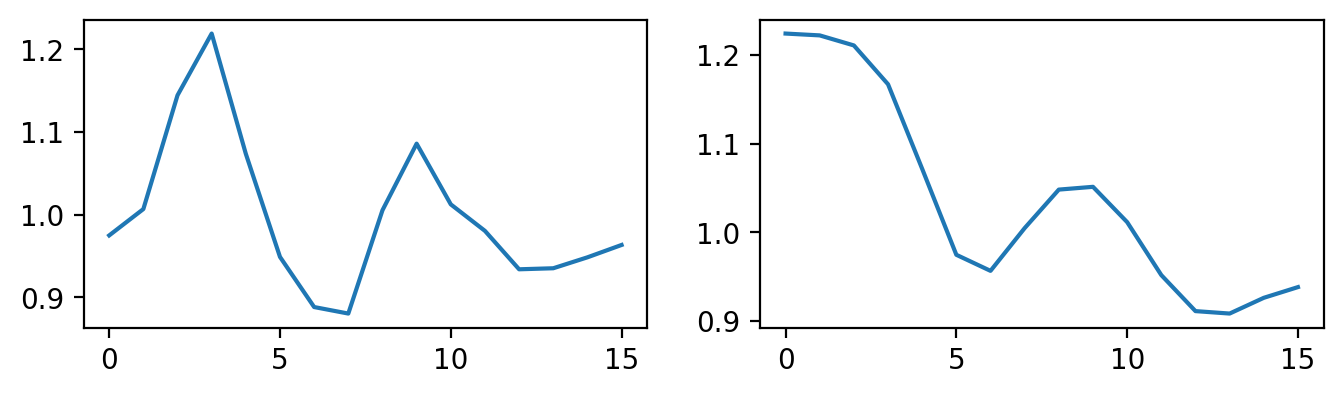

In [445]:
plt.figure(figsize=(8, 2))
plt.subplot(1, 2, 1)
plt.plot(normalized_example_g_1.values)
plt.subplot(1, 2, 2)
plt.plot(predicted_g)